In [1]:
import numpy as np
from copy import deepcopy
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

In [13]:
def cross_validation(X, y, k, model):
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    if len(X) != len(y):
        raise ValueError("X and y must have the same number of observations.")
    if not isinstance(k, int) or k < 2 or k > len(y):
        raise ValueError("k must be an integer from 2 to the number of observations.")

    # Shuffle positions rather than shuffling X and y separately.
    positions = np.random.permutation(len(y))
    partitions = np.array_split(positions, k)
    accuracy_scores = []

    for i in range(k):
        test_positions = partitions[i]
        train_positions = []

        for j in range(k):
            if j != i:
                train_positions.extend(partitions[j])

        X_train = X[train_positions]
        y_train = y[train_positions]
        X_test = X[test_positions]
        y_test = y[test_positions]

        # Start each round with a fresh copy of the unfitted model.
        fold_model = deepcopy(model)
        fold_model.fit(X_train, y_train)
        predictions = fold_model.predict(X_test)

        accuracy = np.mean(predictions == y_test)
        accuracy_scores.append(accuracy)

    return sum(accuracy_scores) / k

In [19]:
iris = load_iris()
X = iris.data
y = iris.target

np.random.seed(42)
model = DecisionTreeClassifier(random_state=42)
cv_accuracy = cross_validation(X, y, 5, model)

print("Cross-validation accuracy:", round(cv_accuracy, 4))

Cross-validation accuracy: 0.9533


In [28]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt

file_path = Path.home() / "Downloads" / "roc_curve_data.csv"

probabilities = []
actual_labels = []

with open(file_path, newline="") as file:
    reader = csv.DictReader(file)

    for row in reader:
        probabilities.append(float(row["Pred_Prob_1"]))
        actual_labels.append(int(row["Actual_Label"]))

print("Number of observations:", len(actual_labels))

Number of observations: 820


In [35]:
true_positive_rates = []
false_positive_rates = []

for step in range(1001):
    cutoff = step / 1000
    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for i in range(len(actual_labels)):
        if probabilities[i] >= cutoff:
            prediction = 1
        else:
            prediction = 0

        if prediction == 1 and actual_labels[i] == 1:
            TP += 1
        elif prediction == 1 and actual_labels[i] == 0:
            FP += 1
        elif prediction == 0 and actual_labels[i] == 0:
            TN += 1
        else:
            FN += 1

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    true_positive_rates.append(TPR)
    false_positive_rates.append(FPR)

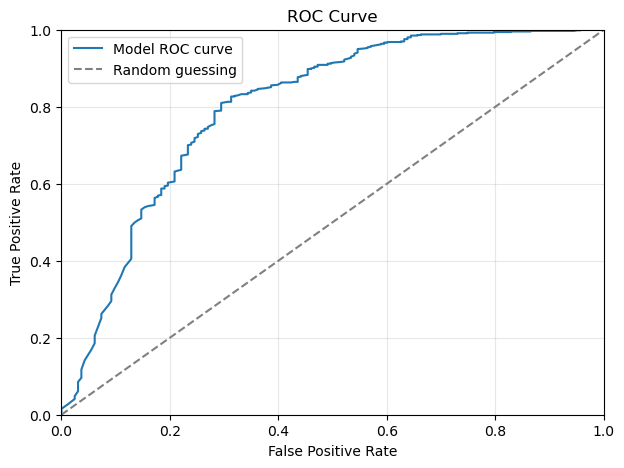

In [38]:
plt.figure(figsize=(7, 5))
plt.plot(false_positive_rates, true_positive_rates, label="Model ROC curve")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()